In [4]:
import os
import wandb
import torch
from tqdm import tqdm

def train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, 
                 func_inputs, func_outputs, epochs, start=0, scheduler=None, accuracy=True,
                 model_path=None, save_epochs=1, tracking=False):

    logs = []
    if tracking:   
        wandb.watch(model, log_freq=100)
        
    # large value for initial best loss
    best_loss = 1e7
    best_acc = 0

    for epoch_idx in range(start, epochs+start):
        print("Epoch: {}/{}".format(epoch_idx+1, epochs+start))

        if accuracy:
            avg_train_loss, avg_train_acc = train(model, loss_func, optimizer, device, train_dl, 
                                            func_inputs, func_outputs, scheduler, accuracy, tracking)
            print("Training Loss: {:.4f}, Training Accuracy: {:.4f}%".format(avg_train_loss, avg_train_acc*100))
        
            avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, valid_dl, 
                              func_inputs, func_outputs, accuracy, tracking)
            print("Validation Loss: {:.4f}, Validation Accuracy: {:.4f}%".format(avg_valid_loss, avg_valid_acc*100))

            if test_dl:
                avg_test_loss, avg_test_acc = valid(model, loss_func, device, test_dl, 
                             func_inputs, func_outputs, accuracy, tracking)
                print("Test Loss: {:.4f}, Test Accuracy: {:.4f}%".format(avg_test_loss, avg_test_acc*100))
          
            metrics = {"epoch": epoch_idx,
                        "train_loss": avg_train_loss, 
                        "valid_loss": avg_valid_loss,
                        "train_acc": avg_train_acc, 
                        "valid_acc": avg_valid_acc} 

            if test_dl:
                metrics["test_loss"]=avg_test_loss
                metrics["test_acc"]=avg_test_acc 
                  
        else:
            avg_train_loss = train(model, loss_func, optimizer, device, train_dl, 
                                            func_inputs, func_outputs, scheduler, accuracy, tracking)
            print("Training Loss: {:.4f}".format(avg_train_loss))
        
            avg_valid_loss = valid(model, loss_func, device, valid_dl, 
                              func_inputs, func_outputs, accuracy, tracking)
            print("Validation Loss: {:.4f}".format(avg_valid_loss))

            if test_dl:
                avg_test_loss = valid(model, loss_func, device, test_dl, 
                             func_inputs, func_outputs, accuracy, tracking)
                print("Test Loss: {:.4f}".format(avg_test_loss))
          
            metrics = {"epoch": epoch_idx,
                        "train_loss": avg_train_loss, 
                        "valid_loss": avg_valid_loss}
            if test_dl:
                metrics["test_loss"]=avg_test_loss
                
        logs.append(metrics)
                  
        if tracking: wandb.log(metrics)
                
        if model_path != None:            
            if (epoch_idx + 1) % save_epochs == 0:
                torch.save(model, os.path.join(model_path+'-epoch-{}.pt'.format(epoch_idx+1)))
            if avg_valid_loss < best_loss:
                torch.save(model, os.path.join(model_path+'-best_loss.pt'))
            if accuracy:
                if avg_valid_acc > best_acc:
                    torch.save(model, os.path.join(model_path+'-best_acc.pt'))
              
    return logs

def train(model, loss_func, optimizer, device, train_dl, func_inputs, func_outputs, scheduler=None, accuracy=True,
          tracking=False):
                  
    model.train()
    train_data_size = len(train_dl.dataset)
    train_loss = 0.0
    train_acc = 0.0

    for i, batch in enumerate(tqdm(train_dl)):
        inputs, labels = func_inputs(batch)
        inputs = inputs.to(device)
        labels = labels.to(device)
        model = model.to(device)
        
        optimizer.zero_grad()
        
        pu_1, pu_2, loss_2, loss_3, loss_4, theta_, theta, mask, affined_mask = func_outputs(model, inputs)
        loss_1 = loss_func(pu_1, pu_2)
        loss = loss_1 + loss_2 + loss_3 + loss_4
            
        train_loss += loss.item() * inputs.size(0)
        loss.backward()

        metrics = {"train_batch_loss": loss,
                   "train_batch_loss_1": loss_1, 
                   "train_batch_loss_area": loss_2, 
                   "train_batch_loss_continuity": loss_3, 
                   "train_batch_loss_sobel": loss_4}
        if accuracy:
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))
            acc = torch.mean(correct_counts.type(torch.FloatTensor))
            train_acc += acc.item() * inputs.size(0)
            metrics['train_batch_acc'] = train_acc
        
        optimizer.step()
        if scheduler:
            scheduler.step()
            
        if tracking: wandb.log(metrics)

    if accuracy:
        avg_train_loss = train_loss/train_data_size 
        avg_train_acc = train_acc/float(train_data_size)
        return avg_train_loss, avg_train_acc
    
    else:
        avg_train_loss = train_loss/train_data_size
        return avg_train_loss


def valid(model, loss_func, device, valid_dl, func_inputs, func_outputs, accuracy=True,
          tracking=False):
                  
    model.eval()
    valid_data_size = len(valid_dl.dataset)
    valid_loss = 0.0
    valid_acc = 0.0
    
    with torch.no_grad():

        for j, batch in enumerate(tqdm(valid_dl)):
            
            inputs, labels = func_inputs(batch)
            inputs = inputs.to(device)
            labels = labels.to(device)
            model = model.to(device)

            pu_1, pu_2, loss_2, loss_3, loss_4, theta_, theta, mask, affined_mask = func_outputs(model, inputs)
            loss_1 = loss_func(pu_1, pu_2)
            loss = loss_1 + loss_2 + loss_3 + loss_4
            
            valid_loss += loss.item() * inputs.size(0)
            metrics = {"valid_batch_loss": loss,
                       "valid_batch_loss_1": loss_1, 
                       "valid_batch_loss_area": loss_2,
                       "valid_batch_loss_continuity": loss_3,
                       "valid_batch_loss_sobel": loss_4}
        
            if accuracy:
                ret, predictions = torch.max(outputs.data, 1)
                correct_counts = predictions.eq(labels.data.view_as(predictions))
                acc = torch.mean(correct_counts.type(torch.FloatTensor))
                valid_acc += acc.item() * inputs.size(0)     
                metrics['valid_batch_acc'] = valid_acc
                
            if tracking: wandb.log(metrics)

    if accuracy:
        avg_valid_loss = valid_loss/valid_data_size 
        avg_valid_acc = valid_acc/float(valid_data_size)
        return avg_valid_loss, avg_valid_acc
    
    else:
        avg_valid_loss = valid_loss/valid_data_size 
        return avg_valid_loss

In [6]:
NAME = 'replace_sobel_with_continuity-retrain'
os.environ["WANDB_NOTEBOOK_NAME"] = nb_name

wandb.init(project='Attention_mask_model', entity='yig319', save_code=True, name=NAME, id=NAME)

wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [7]:
device = torch.device('cuda:3')

lr = 1e-3
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# sobel_loss_func = Sobel_loss(coef=0)
sobel_loss_func = continuity_loss(kernel=3, stride=1, coef=0.1)
continuity_loss_func = continuity_loss(kernel=3, stride=1, coef=0.1)
area_loss_func = area_loss(upper_limit=5**2, lower_limit=2**2, coef=10)

def func_inputs(batch):
    inputs = batch[0].float()
    labels = batch[1].long()
    return inputs, labels

In [8]:
start = 0
epochs = 10
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

logs = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, None,
                    func_inputs, run_workflow, epochs, start, scheduler, accuracy=False,
                    model_path='/scratch/yichen/models/'+NAME, save_epochs=1000, tracking=True)

Epoch: 1/10


100%|██████████| 196/196 [02:41<00:00,  1.21it/s]


Training Loss: 116718.4851


100%|██████████| 40/40 [00:17<00:00,  2.24it/s]


Validation Loss: 116310.7322
Epoch: 2/10


...

Validation Loss: 90895.9932
Epoch: 10/10


100%|██████████| 196/196 [02:47<00:00,  1.17it/s]


Training Loss: 90896.1880


100%|██████████| 40/40 [00:21<00:00,  1.83it/s]


Validation Loss: 90895.6549


In [4]:
model = models.resnet50()

model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),

                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                        )

In [5]:
model(torch.randn(2,3,256,256)).shape

torch.Size([2, 17])

# train

In [6]:
config = {
    'device': torch.device('cuda:0'),
    'batch_size': bs,
    
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = 'benchmark-resnet50-from_scratch-05232022'

wandb.init(project='Symmetry-benchmark', entity='yig319', 
           name=NAME, config=config, id=NAME)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319 (use `wandb login --relogin` to force relogin)
wandb: wandb version 0.12.16 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade


In [7]:
# NAME = 'benchmark-resnet50_2spatial-from_scratch-1e-5'
# 'device': torch.device('cuda:1')

device = config['device']
lr = 1e-3
epochs = 10

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=0,
                       scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 1/10


100%|██████████| 7947/7947 [30:06<00:00,  4.40it/s]  


Training: Loss: 2.2236, Accuracy: 24.6472%, Time: 1806.7295s


100%|██████████| 7531/7531 [10:14<00:00, 12.25it/s]


Validation : Loss : 1.2767, Accuracy: 52.7253%, Time: 614.6863s


...

Training: Loss: 0.0711, Accuracy: 97.8034%, Time: 1802.1478s


100%|██████████| 7531/7531 [10:18<00:00, 12.18it/s]


Validation : Loss : 0.1062, Accuracy: 96.6409%, Time: 618.2025s


100%|██████████| 2000/2000 [02:44<00:00, 12.15it/s]


Validation : Loss : 2.9655, Accuracy: 49.0509%, Time: 164.5889s


In [8]:
# NAME = 'benchmark-resnet50_2spatial-from_scratch-1e-5'
# 'device': torch.device('cuda:1')

device = config['device']
lr = 1e-3
epochs = 20
start = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start,
                       scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 21/40


100%|██████████| 7947/7947 [30:21<00:00,  4.36it/s]  


Training: Loss: 0.0705, Accuracy: 97.8217%, Time: 1821.9442s


100%|██████████| 7531/7531 [10:20<00:00, 12.13it/s]


Validation : Loss : 0.1108, Accuracy: 96.5388%, Time: 620.7603s


...

Training: Loss: 0.0083, Accuracy: 99.7673%, Time: 1858.4441s


100%|██████████| 7531/7531 [10:16<00:00, 12.22it/s]


Validation : Loss : 0.1042, Accuracy: 97.8262%, Time: 616.2412s


100%|██████████| 2000/2000 [02:43<00:00, 12.23it/s]


Validation : Loss : 4.1895, Accuracy: 51.6921%, Time: 163.5977s


In [7]:
NAME

'benchmark-resnet50-from_scratch-05232022'

In [8]:
model = torch.load('/scratch/yichen/models/benchmark-resnet50-from_scratch-05232022-epoch-40.pt')

In [9]:
device = config['device']
lr = 1e-3
epochs = 20
start = 40

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start,
                       scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 41/60


100%|██████████| 7947/7947 [30:16<00:00,  4.38it/s]  


Training: Loss: 0.0086, Accuracy: 99.7551%, Time: 1816.0778s


100%|██████████| 7531/7531 [10:21<00:00, 12.11it/s]


Validation : Loss : 0.1071, Accuracy: 97.7747%, Time: 621.8907s


...

Training: Loss: 0.0044, Accuracy: 99.8764%, Time: 1791.2769s


100%|██████████| 7531/7531 [10:18<00:00, 12.17it/s]


Validation : Loss : 0.1115, Accuracy: 97.9463%, Time: 618.6243s


100%|██████████| 2000/2000 [02:44<00:00, 12.14it/s]


Validation : Loss : 4.6462, Accuracy: 52.0376%, Time: 164.7705s


In [21]:
device = config['device']
lr = 1e-3
epochs = 20
start = 60

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start,
                       scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 61/80


100%|██████████| 7947/7947 [33:39<00:00,  3.94it/s]  


Training: Loss: 0.0046, Accuracy: 99.8657%, Time: 2019.3544s


100%|██████████| 7531/7531 [10:29<00:00, 11.96it/s]


Validation : Loss : 0.1172, Accuracy: 97.9010%, Time: 629.8632s


...

Training: Loss: 0.0034, Accuracy: 99.9051%, Time: 1908.2261s


100%|██████████| 7531/7531 [10:55<00:00, 11.48it/s]


Validation : Loss : 0.1186, Accuracy: 97.9767%, Time: 655.8178s


100%|██████████| 2000/2000 [02:48<00:00, 11.86it/s]


Validation : Loss : 4.9942, Accuracy: 49.8905%, Time: 168.5742s


In [22]:
device = config['device']
lr = 1e-3
epochs = 20
start = 80

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start,
                       scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 81/100


100%|██████████| 7947/7947 [35:22<00:00,  3.74it/s]  


Training: Loss: 0.0034, Accuracy: 99.9063%, Time: 2122.1764s


100%|██████████| 7531/7531 [10:51<00:00, 11.56it/s]


Validation : Loss : 0.1241, Accuracy: 97.9473%, Time: 651.3683s


...

100%|██████████| 7531/7531 [10:42<00:00, 11.72it/s]


Validation : Loss : 0.1237, Accuracy: 98.0196%, Time: 642.4439s


100%|██████████| 2000/2000 [02:46<00:00, 12.00it/s]


Validation : Loss : 5.3254, Accuracy: 48.5529%, Time: 166.7360s


wandb: 500 encountered ({"error":"dial tcp 35.226.229.132:3307: connect: connection refused"}), retrying request
wandb: Network error resolved after 0:05:40.908589, resuming normal operation.


# analyze

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

# imagenet 
def confusion_matrix(model, dataloader, classes, device, n_batches=1):
    model.eval()
    cm = torch.zeros(len(classes), len(classes))
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):

            inputs = inputs.to(device) 
            labels = labels.to(device)
            model = model.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1
#             if n_batches == i + 1:
#                 break
    cm = np.array(cm)
                
#     fig = plt.figure(figsize=(12,10))
#     ax = fig.subplots(1,1)
#     ax.set_title('Confusion Matrix')
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
#     disp = disp.plot(cmap=plt.cm.Blues, ax=ax)
#     plt.show()
    
    print('Sum for true labels:')
    true_counts = np.expand_dims(np.sum(cm, axis=1), 0)
    display(pd.DataFrame(true_counts, columns=classes))

    wrong, right = 0, 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j: right+=cm[i,j]
            if i != j: wrong+=cm[i,j]
    print('Accuracy for these batches:', right/(right+wrong))
    return cm.astype(np.int32)

def plot_cm(cm, classes, save_file, title, style='simple'):

    if style == 'simple':
        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp = disp.plot(cmap=plt.cm.Blues, ax=ax)

    if style== 'with_axis':
        df_cm = pd.DataFrame(cm)
        df_cm.index.name = 'Actual'
        df_cm.columns.name = 'Predicted'

        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        res = sn.heatmap(df_cm, annot=True, square=True, cmap='Blues',
                         xticklabels = classes, yticklabels=classes, fmt='g', 
                         ax=ax, cbar_kws={'label': 'Number of Images'})

        res.axhline(y = 0, color = 'k', 
                    linewidth = 1)
        res.axhline(y = 16.98, color = 'k',
                    linewidth = 1)
        res.axvline(x = 0, color = 'k',
                    linewidth = 1)
        res.axvline(x = 16.98, color = 'k',
                    linewidth = 1)
    
    if save_file: plt.savefig(save_file, dpi=300)
    plt.show()


symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

In [24]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save('05232022-benchmark-resnet50_from_scratch-dataset_v3-train.npy', cm)

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,46851.0,46837.0,46522.0,46547.0,47014.0,46745.0,46011.0,46915.0,46931.0,46916.0,46874.0,45985.0,46907.0,46876.0,46911.0,46907.0,46924.0


Accuracy for these batches: 0.9995847348532038


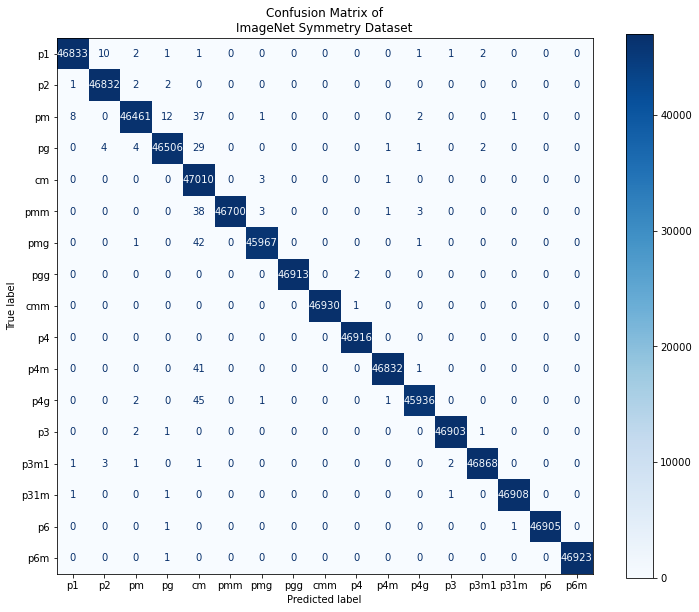

In [25]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [26]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save('05232022-benchmark-resnet50_from_scratch-dataset_v3-valid.npy', cm)

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,46892.0,46864.0,46553.0,46544.0,47012.0,46787.0,29226.0,46905.0,46904.0,46918.0,33452.0,34487.0,46889.0,46891.0,46894.0,46905.0,46900.0


Accuracy for these batches: 0.9801958240319353


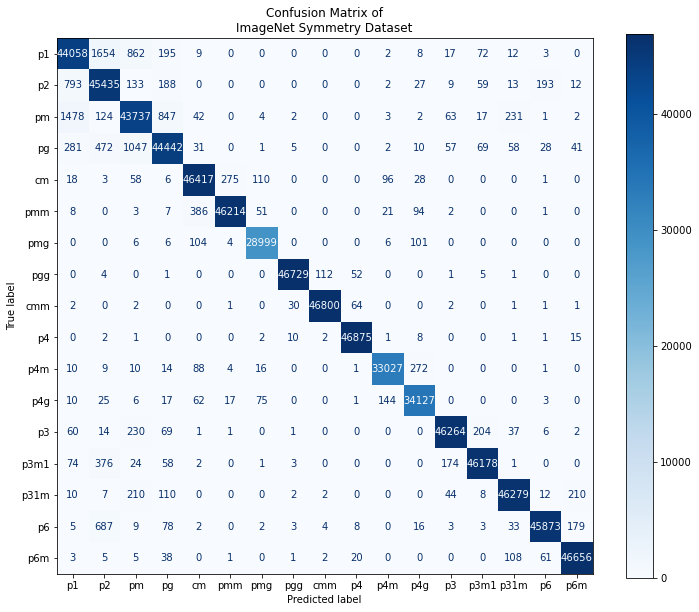

In [27]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [28]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy', cm)

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0


Accuracy for these batches: 0.48552913174790485


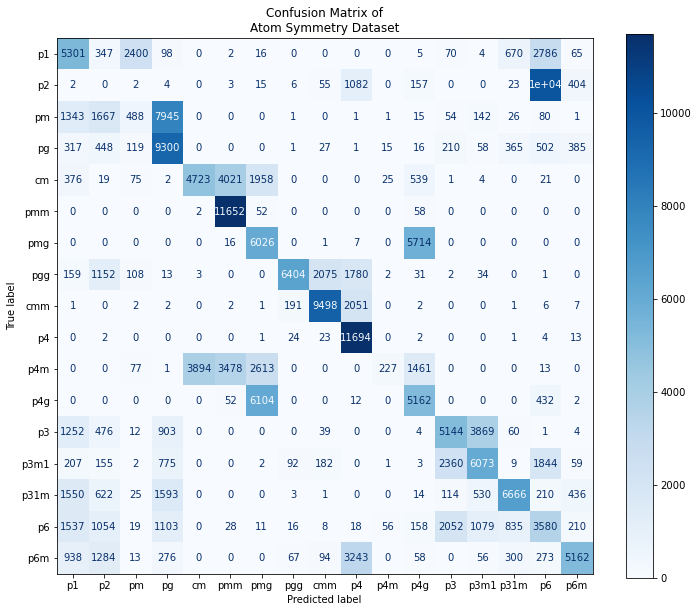

In [29]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')